In [18]:
# Adjust the working directly to import packages using the root package
import sys
import os

notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/slt-examples


In [17]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.mixture import GaussianMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

In [3]:
dgp_data = {
    "id": [str(i) for i in range(4)],
    "n": np.ones(10000),
    "rho1": np.array([0.3, 0.3, 0.01, 0]),
    "p1": np.ones(6) * 0,
    "p2": np.ones(6) * 0,
}
dgp_data["rho2"] = 1 - dgp_data["rho1"]
dgp_df = pd.DataFrame(dgp_data).set_index("id")
# save the experiment meta
dgp_pathstr = "./data/dgp.csv"
dgp_df.to_csv(dgp_pathstr)
dgp_df.head()

,rho1,mu1,sigma1,mu2,sigma2,rho2
id,,,,,,
0,0.5,0.0,1.0,20.0,3.0,0.5
1,0.5,0.0,1.0,10.0,3.0,0.5
2,0.5,0.0,1.0,5.0,3.0,0.5
3,0.5,0.0,1.0,2.5,3.0,0.5
4,0.5,0.0,1.0,1.5,3.0,0.5


In [4]:
class MvnMix:
    def __init__(self, k: int, rho, mu, sigma):
        self.k = k
        if k != len(mu) or k != len(rho) or k != len(sigma):
            raise ValueError("all parameters must be of the same dimension")

        self.rho = rho
        self.mu = mu
        self.sigma = sigma
        self.k = len(mu)

    def sample(self, n):
        samples = np.zeros(n)
        dist_indices = np.random.choice(a=np.arange(self.k), size=n, p=self.rho)
        for i in range(n):
            dindex = dist_indices[i]
            loc = self.mu[dindex]
            scale = self.sigma[dindex]
            samples[i] = np.random.normal(loc=loc, scale=scale, size=1).item()

        return samples

In [5]:
obs_pathstr = "./data/n{n}.csv"
n = 10000

file = Path(obs_pathstr.format(n=n))
if file.exists():  # check if this data has already been generated
    print(f"File {file} exists, n={n} random sample creation skipped!")
else:
    if file.parent:  # create parents dir if not already
        file.parent.mkdir(parents=True, exist_ok=True)
    data = {}
    for i in range(6):  # iterate over experiments
        dd = MvnMix(
            k=2,
            rho=dgp_df.loc[f"{i}", ["rho1", "rho2"]].tolist(),
            mu=dgp_df.loc[f"{i}", ["mu1", "mu2"]].tolist(),
            sigma=dgp_df.loc[f"{i}", ["sigma1", "sigma2"]].tolist(),
        )

        data[str(i)] = dd.sample(n=n)
    obs = pd.DataFrame(data)
    obs.to_csv(file)
    # np.savetxt(
    #     file, obs,
    #     delimiter=',',          # Use semicolon as delimiter
    #     comments='# '           # Use '# ' as the comment character
    # )
    print(f"Created {file} with {n} random samples")

File data/n10000.csv exists, n=10000 random sample creation skipped!


In [6]:
data = pd.read_csv(file, index_col=0)
data.head()

,0,1,2,3,4,5
0,-0.283785,14.108498,1.113577,5.388160,0.177895,-2.080764
1,0.837490,9.893297,0.561764,9.647621,-1.185107,-0.937669
2,0.394400,9.221056,1.121630,0.638172,-1.018421,3.350077
3,26.663167,11.119676,7.902362,3.810201,-0.121573,-4.117567
4,0.088968,13.860417,1.032638,3.994683,1.352027,0.425766


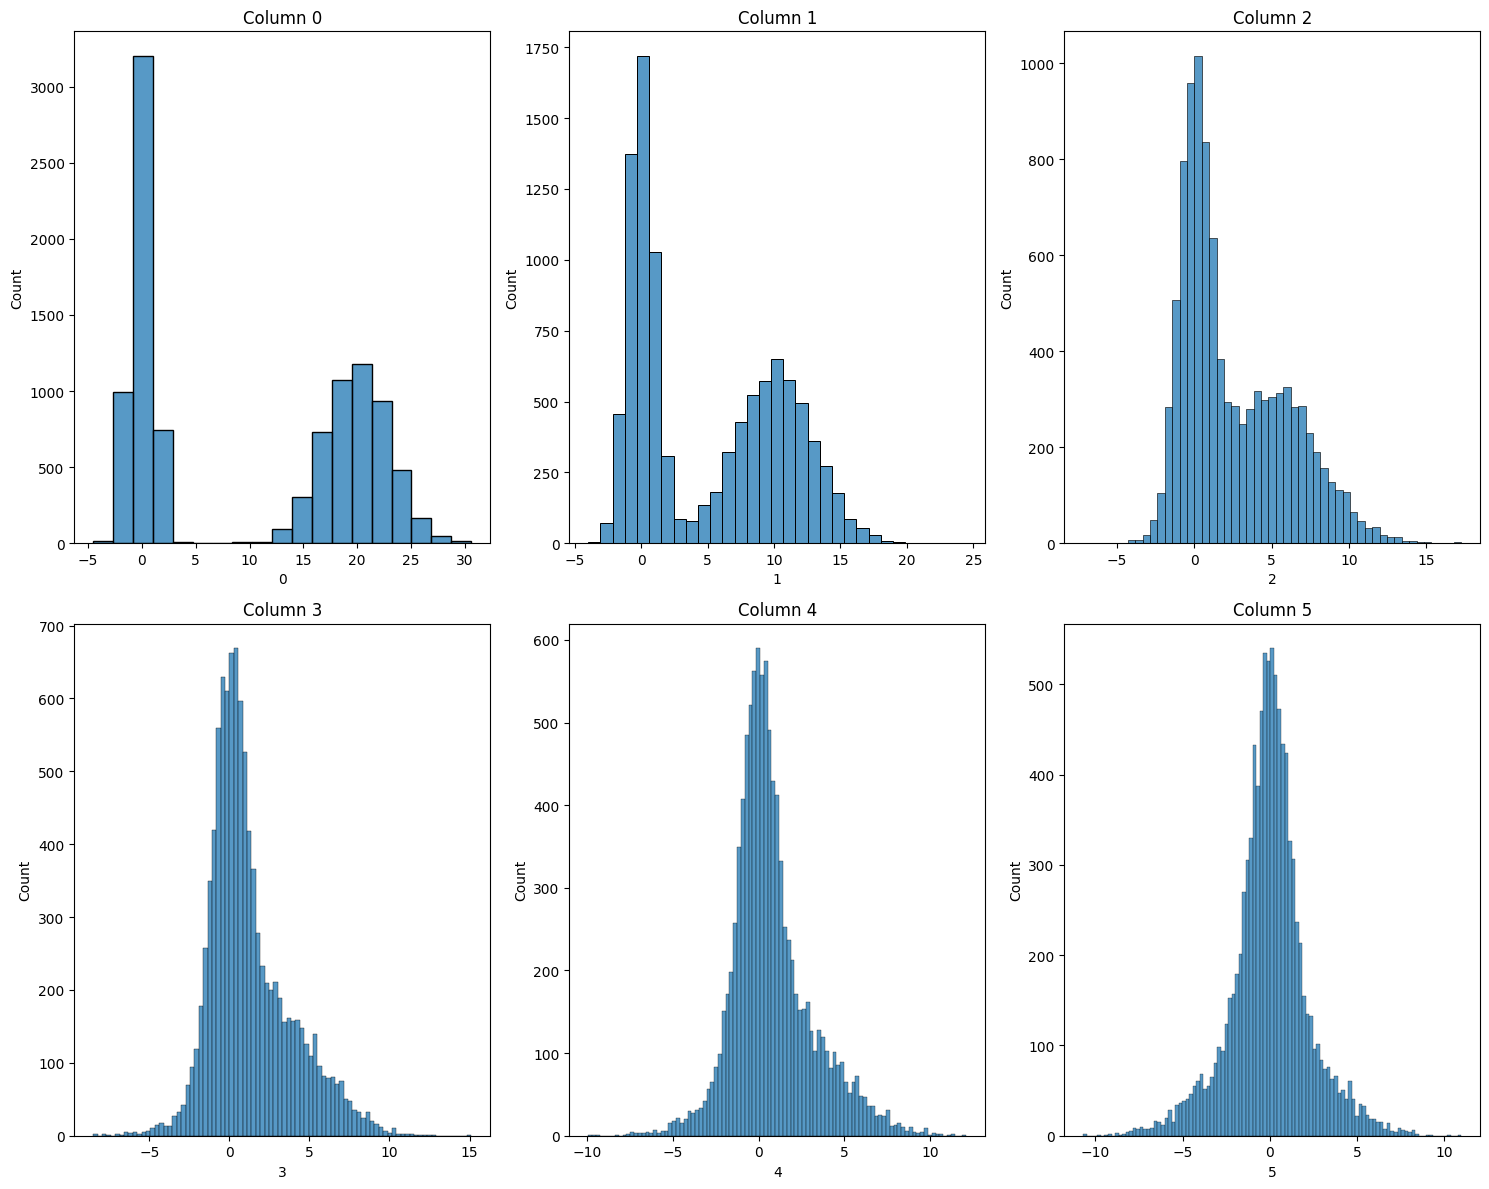

In [7]:
# Calculate grid dimensions
n_cols = len(data.columns)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 6 * 2))
axes = axes.flatten() if n_cols > 1 else [axes]

# Create histogram for each column
for i, col in enumerate(data.columns):
    sns.histplot(data[col], ax=axes[i])
    axes[i].set_title(f"Column {col}")

# Hide empty subplots
for i in range(n_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
def bootstrap_percentile(data, percentile=95, n_bootstrap=1000):
    """
    Compute bootstrap confidence interval for a percentile
    """
    bootstrap_percentiles = []
    n = len(data)

    for _ in range(n_bootstrap):
        # Resample with replacement
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        # Compute percentile for this bootstrap sample
        boot_percentile = np.percentile(bootstrap_sample, percentile)
        bootstrap_percentiles.append(boot_percentile)

    return np.array(bootstrap_percentiles)


# Initialize the GMM
# def compute_mle(x_obs, sigma, max_iter=10**6, tol=10e-4, n_bootstrap=500):
#     gmm = GaussianMixture(n_components=2,
#                           covariance_type='diag',
#                           max_iter=1, random_state=42, warm_start=True)

#     # Initialize some reasonable inits
#     gmm.weights_ = np.random.uniform(size=2)
#     gmm.covariances_ = np.array([[sigma[0]], [sigma[1]]])
#     gmm.means_ = np.array([[x_obs.min()], [x_obs.max()]]) # Simple initialization
#     gmm.precisions_cholesky_ = 1.0 / np.sqrt(gmm.covariances_)

#     print("Init parameters")
#     print(f"Means: {[f'{x:.2f}' for x in gmm.means_.flatten()]}")
#     print(f"Variances: {gmm.covariances_.flatten()}")
#     print(f"Weights: {[f'{x:.2f}' for x in gmm.weights_.flatten()]}")
#     gmm.tol = tol
#     gmm.max_iter = max_iter
#     gmm.fit(x_obs.values.reshape(-1,1))

#     means = gmm.means_.flatten()
#     weights = gmm.weights_.flatten()
#     if means[0] >= means[1]:
#         ll = 1
#         hh = 0
#     else:
#         ll=0
#         hh=1

#     mle={
#         "mu1":means[ll],
#         "mu2":means[hh],
#         "rho1":weights[ll],
#         "rho2":weights[hh]
#     }

#     print(f"MLE estimates {mle}")
#     # Bootstrap for comparison
#     print(f"Let's compute the mle confidence regions using bootstrap!")
#     mu1 = []
#     mu2 = []
#     rho1 = []
#     rho2 = []


# for i in tqdm(range(n_bootstrap), desc="Processing"):
#     X_boot = resample(x_obs, random_state=i, n_samples=int(len(x_obs)*.7))
#     gmm_boot = GaussianMixture(n_components=2, random_state=i)
#     gmm_boot.fit(X_boot.values.reshape(-1,1))
#     gmm_boot.covariances_ = np.array([[w0["sigma1"]**2], [w0["sigma2"]**2]])

#     means = gmm_boot.means_.flatten()
#     weights = gmm_boot.weights_.flatten() # sort out the samples to ensure estimates aren't
#     if means[0] >= means[1]:
#         ll = 1
#         hh = 0
#     else:
#         ll=0
#         hh=1

#     means = gmm_boot.means_.flatten()
#     weights = gmm_boot.weights_.flatten()

#     mu1.append(means[ll])
#     mu2.append(means[hh])
#     rho1.append(weights[ll])
#     rho2.append(weights[hh])
#     clear_output(wait=True)


# estimates={
#     "n": len(x_obs),
#     "mle": mle,
#     "ci_lower": {
#         "rho1": np.percentile(rho1, 2.5),
#         "rho2": np.percentile(rho2, 2.5),
#         "mu1": np.percentile(mu1, 2.5),
#         "mu2": np.percentile(mu2, 2.5),
#     },
#     "ci_upper": {
#         "rho1": np.percentile(rho1, 97.5),
#         "rho2": np.percentile(rho2, 97.5),
#         "mu1": np.percentile(mu1, 97.5),
#         "mu2": np.percentile(mu2, 97.5),
#     }
# }
# return estimates
def compute_mle(x_obs, sigma, max_iter=10**6, tol=10e-4, n_bootstrap=500):
    # Fit main GMM
    gmm = GaussianMixture(
        n_components=2,
        covariance_type="diag",
        max_iter=max_iter,
        tol=tol,
        random_state=42,
    )

    gmm.fit(x_obs.values.reshape(-1, 1))

    # Extract and sort main estimates
    means = gmm.means_.flatten()
    weights = gmm.weights_.flatten()

    # Sort by means to handle label switching
    if means[0] <= means[1]:  # mu1 should be smaller
        ll, hh = 0, 1
    else:
        ll, hh = 1, 0

    mle = {"mu1": means[ll], "mu2": means[hh], "rho1": weights[ll], "rho2": weights[hh]}

    print(f"MLE estimates {mle}")

    # Bootstrap
    print("Computing bootstrap confidence intervals...")
    mu1_boot, mu2_boot, rho1_boot, rho2_boot = [], [], [], []

    for i in tqdm(range(n_bootstrap), desc="Bootstrap"):
        try:
            # Resample with replacement (full sample size)
            X_boot = resample(x_obs.values, random_state=i, n_samples=len(x_obs))

            # Fit bootstrap GMM
            gmm_boot = GaussianMixture(
                n_components=2,
                covariance_type="diag",
                max_iter=1000,  # Reduce iterations for speed
                random_state=i,
                n_init=3,
            )  # Multiple initializations

            gmm_boot.fit(X_boot.reshape(-1, 1))

            # Check convergence
            if not gmm_boot.converged_:
                continue  # Skip non-converged fits

            means_boot = gmm_boot.means_.flatten()
            weights_boot = gmm_boot.weights_.flatten()

            # Handle label switching by sorting means
            if means_boot[0] <= means_boot[1]:
                ll_boot, hh_boot = 0, 1
            else:
                ll_boot, hh_boot = 1, 0

            mu1_boot.append(means_boot[ll_boot])
            mu2_boot.append(means_boot[hh_boot])
            rho1_boot.append(weights_boot[ll_boot])
            rho2_boot.append(weights_boot[hh_boot])

        except Exception as e:
            # Skip failed fits
            print(f"Bootstrap iteration {i} failed: {e}")
            continue

    print(f"Successful bootstrap samples: {len(mu1_boot)}/{n_bootstrap}")

    if len(mu1_boot) < 50:  # Too few successful samples
        print("Warning: Very few successful bootstrap samples!")
        return {"error": "Bootstrap failed - too few successful samples"}

    estimates = {
        "n": len(x_obs),
        "mle": mle,
        "bootstrap_samples": {
            "mu1": mu1_boot,
            "mu2": mu2_boot,
            "rho1": rho1_boot,
            "rho2": rho2_boot,
        },
        "ci_lower": {
            "mu1": np.percentile(mu1_boot, 2.5),
            "mu2": np.percentile(mu2_boot, 2.5),
            "rho1": np.percentile(rho1_boot, 2.5),
            "rho2": np.percentile(rho2_boot, 2.5),
        },
        "ci_upper": {
            "mu1": np.percentile(mu1_boot, 97.5),
            "mu2": np.percentile(mu2_boot, 97.5),
            "rho1": np.percentile(rho1_boot, 97.5),
            "rho2": np.percentile(rho2_boot, 97.5),
        },
    }

    return estimates

In [13]:
# Set the known variances
n_steps = np.arange(2000, n + 2000, 2000)
mle_data = {}
for i in range(6):
    w0 = dgp_df.loc[f"{i}"]
    x_obs = data[f"{i}"]
    for nn in n_steps:
        estimates = compute_mle(
            x_obs=x_obs[:nn],
            sigma=np.array([w0["sigma1"] ** 2, w0["sigma2"] ** 2]),
            n_bootstrap=2000,
            max_iter=10**10,
            tol=10e-5,
        )
        # Assuming your data looks like this:
        if f"dataset_{i}" not in mle_data:
            mle_data[f"dataset_{i}"] = {
                "n": [],
                "ml": {"rho": [], "mu1": [], "mu2": []},
                "ci_lower": {"rho": [], "mu1": [], "mu2": []},
                "ci_upper": {"rho": [], "mu1": [], "mu2": []},
            }

        ds = mle_data.get(f"dataset_{i}")
        ds["n"].append(nn)
        ds["ml"]["rho"].append(estimates["mle"]["rho1"])
        ds["ci_lower"]["rho"].append(estimates["ci_lower"]["rho1"])
        ds["ci_upper"]["rho"].append(estimates["ci_upper"]["rho1"])

        ds["ml"]["mu1"].append(estimates["mle"]["mu1"])
        ds["ci_lower"]["mu1"].append(estimates["ci_lower"]["mu1"])
        ds["ci_upper"]["mu1"].append(estimates["ci_upper"]["mu1"])

        ds["ml"]["mu2"].append(estimates["mle"]["mu2"])
        ds["ci_lower"]["mu2"].append(estimates["ci_lower"]["mu2"])
        ds["ci_upper"]["mu2"].append(estimates["ci_upper"]["mu2"])

MLE estimates {'mu1': np.float64(-0.04302054481235603), 'mu2': np.float64(20.084444939061555), 'rho1': np.float64(0.49499997244353267), 'rho2': np.float64(0.5050000275564672)}
Computing bootstrap confidence intervals...


Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Successful bootstrap samples: 2000/2000
MLE estimates {'mu1': np.float64(-0.018609228189549763), 'mu2': np.float64(20.023777514746232), 'rho1': np.float64(0.4952499918666602), 'rho2': np.float64(0.5047500081333398)}
Computing bootstrap confidence intervals...


Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Successful bootstrap samples: 2000/2000
MLE estimates {'mu1': np.float64(-0.01401221328672959), 'mu2': np.float64(20.019911006952224), 'rho1': np.float64(0.48866665055720426), 'rho2': np.float64(0.5113333494427957)}
Computing bootstrap confidence intervals...


...

Successful bootstrap samples: 2000/2000
MLE estimates {'mu1': np.float64(-0.08829453476910946), 'mu2': np.float64(0.042064178400628996), 'rho1': np.float64(0.44479978198875886), 'rho2': np.float64(0.5552002180112412)}
Computing bootstrap confidence intervals...


Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Successful bootstrap samples: 2000/2000
MLE estimates {'mu1': np.float64(-0.04974659151853474), 'mu2': np.float64(0.02093515166973337), 'rho1': np.float64(0.4515457809765194), 'rho2': np.float64(0.5484542190234807)}
Computing bootstrap confidence intervals...


Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Successful bootstrap samples: 2000/2000


In [14]:
# Plot the results
def plot_percentile_results(data):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, dataset in enumerate([f"dataset_{j}" for j in range(0, 6)]):
        ax = axes[i]

        x = data[dataset]["n"]
        y = data[dataset]["ml"]["mu2"]
        ci_lower = data[dataset]["ci_lower"]["mu2"]
        ci_upper = data[dataset]["ci_upper"]["mu2"]

        # Plot estimate
        ax.plot(x, y, "o-", color="blue", markersize=4)

        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color="blue")

        ax.set_title(f"Dataset {i + 1} - 95th Percentile")
        ax.set_xlabel("Sample Size")
        ax.set_ylabel("95th Percentile Estimate")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

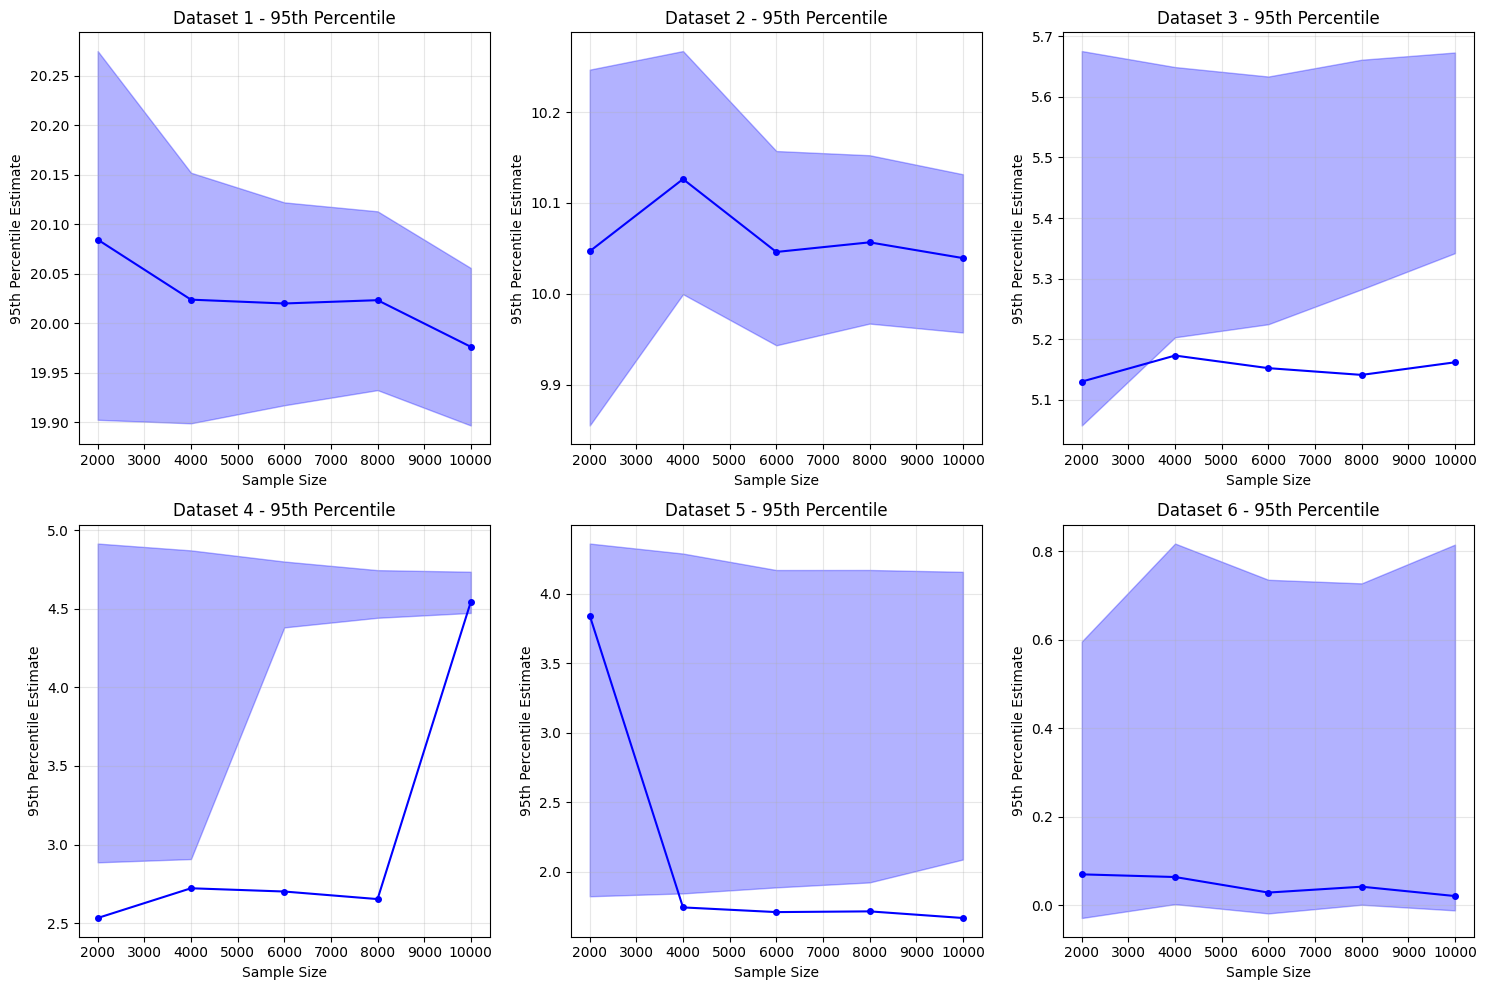

{'dataset_0': {'n': [np.int64(2000),
   np.int64(4000),
   np.int64(6000),
   np.int64(8000),
   np.int64(10000)],
  'ml': {'rho': [np.float64(0.49499997244353267),
    np.float64(0.4952499918666602),
    np.float64(0.48866665055720426),
    np.float64(0.4913749870773613),
    np.float64(0.49679998800828906)],
   'mu1': [np.float64(-0.04302054481235603),
    np.float64(-0.018609228189549763),
    np.float64(-0.01401221328672959),
    np.float64(0.006554713423247086),
    np.float64(-0.007684200279908376)],
   'mu2': [np.float64(20.084444939061555),
    np.float64(20.023777514746232),
    np.float64(20.019911006952224),
    np.float64(20.023246414109156),
    np.float64(19.976095895574097)]},
  'ci_lower': {'rho': [np.float64(0.4724999760120093),
    np.float64(0.47949374200876826),
    np.float64(0.4756666531622988),
    np.float64(0.4806249867611313),
    np.float64(0.4866999898465488)],
   'mu1': [np.float64(-0.10894168199617298),
    np.float64(-0.062233987208521135),
    np.float64

In [15]:
plot_percentile_results(mle_data)
mle_data

In [ ]:
# print(f"{estimates["mle"]['mu1']:.3f}, {estimates["mle"]['mu2']:.3f}")
# print(f"{estimates["mle"]['rho1']:.3f}, {estimates["mle"]['rho2']:.3f}")
# print(f"{w0['mu1']:.3f}, {w0['mu2']:.3f}")
# print(f"{w0['rho1']:.3f}, {w0['rho2']:.3f}")


plt.figure(figsize=(10, 6))
plt.errorbar(
    range(len(parameters)), mle_values, yerr=std_errors, fmt="o", capsize=5, capthick=2
)
plt.xticks(range(len(parameters)), parameters)
plt.ylabel("Values")
plt.title("MLE Estimates with Error Bars (from variance samples)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
data["5"]
plt.hist(data["5"].tolist())